In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score,auc,accuracy_score
%matplotlib inline

<h2>Read Data</h2>

In [51]:
df=pd.read_csv("./Data/train_data.csv")
df.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [52]:
df['class'].value_counts()

0    40
1    40
2    40
Name: class, dtype: int64

In [53]:
y=df['class']
X=df.drop(labels="class",axis=1)
X.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [54]:
y

0      0
1      0
2      0
3      0
4      0
      ..
115    2
116    2
117    2
118    2
119    2
Name: class, Length: 120, dtype: int64

<h2>Model 1: SVC Polynomial Kernel</h2>

<h2>Hyperparameter Tuning</h2>

In [55]:
C=[0.01,0.03,0.1,0.3,1,3,10,30,100]
sigma=[0.01,0.03,0.1,0.3,1,3,10,30,100]

params={'C':C,'gamma':sigma,'kernel':['poly']}

In [56]:
cols=X.columns
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X),columns=cols)
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


In [57]:
X_train.describe().apply(lambda s:s.apply('{0:.5f}'.format))

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
count,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,...,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000
mean,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,...,-0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000
std,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,...,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419
min,-1.10782,-1.71325,-3.25142,-3.25142,-1.85066,-1.88742,-1.45906,-1.63607,-1.39430,-1.92654,...,-1.12825,-1.11484,-1.14304,-1.38843,-1.71325,-1.66166,-2.71528,-2.16523,-1.95276,-2.30449
25%,-0.84141,-0.72594,-0.71643,-0.71643,-0.71068,-0.73506,-0.88587,-1.18085,-0.93072,-0.91649,...,-0.84597,-0.86967,-0.81486,-0.92665,-0.72594,-0.91464,-0.62578,-0.85113,-0.84385,-0.78033
50%,-0.49025,-0.03014,0.29667,0.29667,-0.12936,-0.17730,-0.20096,0.33584,-0.29086,0.27402,...,-0.47507,-0.48426,-0.46897,-0.30061,-0.03014,-0.05804,0.11575,0.01612,0.22050,0.04977
75%,0.94049,0.73300,0.74875,0.74875,0.63854,0.56298,0.82877,0.93264,1.03107,0.91376,...,0.92337,1.07730,0.81028,1.06398,0.73300,0.89910,0.73559,1.11472,0.89683,0.75780
max,2.52279,2.59675,1.59095,1.59095,3.58591,3.39018,1.95489,1.28409,1.78031,1.34333,...,2.49454,2.10580,3.11322,1.74849,2.59675,1.67822,2.55872,1.27789,1.41853,1.66159


In [58]:
grid_s=GridSearchCV(SVC(),params,refit=True,verbose=3)
grid_s.fit(X_train,y)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END ...C=0.01, gamma=0.01, kernel=poly;, score=0.708 total time=   0.0s
[CV 2/5] END ...C=0.01, gamma=0.01, kernel=poly;, score=0.625 total time=   0.0s
[CV 3/5] END ...C=0.01, gamma=0.01, kernel=poly;, score=0.833 total time=   0.0s
[CV 4/5] END ...C=0.01, gamma=0.01, kernel=poly;, score=0.667 total time=   0.0s
[CV 5/5] END ...C=0.01, gamma=0.01, kernel=poly;, score=0.625 total time=   0.0s
[CV 1/5] END ...C=0.01, gamma=0.03, kernel=poly;, score=0.708 total time=   0.0s
[CV 2/5] END ...C=0.01, gamma=0.03, kernel=poly;, score=0.625 total time=   0.0s
[CV 3/5] END ...C=0.01, gamma=0.03, kernel=poly;, score=0.833 total time=   0.0s
[CV 4/5] END ...C=0.01, gamma=0.03, kernel=poly;, score=0.667 total time=   0.0s
[CV 5/5] END ...C=0.01, gamma=0.03, kernel=poly;, score=0.625 total time=   0.0s
[CV 1/5] END ....C=0.01, gamma=0.1, kernel=poly;, score=0.708 total time=   0.0s
[CV 2/5] END ....C=0.01, gamma=0.1, kernel=poly

[CV 3/5] END ......C=0.1, gamma=30, kernel=poly;, score=0.875 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=30, kernel=poly;, score=0.750 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=30, kernel=poly;, score=0.792 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=100, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=100, kernel=poly;, score=0.875 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=100, kernel=poly;, score=0.875 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=100, kernel=poly;, score=0.750 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=100, kernel=poly;, score=0.792 total time=   0.0s
[CV 1/5] END ....C=0.3, gamma=0.01, kernel=poly;, score=0.708 total time=   0.0s
[CV 2/5] END ....C=0.3, gamma=0.01, kernel=poly;, score=0.625 total time=   0.0s
[CV 3/5] END ....C=0.3, gamma=0.01, kernel=poly;, score=0.833 total time=   0.0s
[CV 4/5] END ....C=0.3, gamma=0.01, kernel=poly;, score=0.667 total time=   0.0s
[CV 5/5] END ....C=0.3, gamm

[CV 1/5] END .........C=3, gamma=3, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END .........C=3, gamma=3, kernel=poly;, score=0.875 total time=   0.0s
[CV 3/5] END .........C=3, gamma=3, kernel=poly;, score=0.875 total time=   0.0s
[CV 4/5] END .........C=3, gamma=3, kernel=poly;, score=0.750 total time=   0.0s
[CV 5/5] END .........C=3, gamma=3, kernel=poly;, score=0.792 total time=   0.0s
[CV 1/5] END ........C=3, gamma=10, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END ........C=3, gamma=10, kernel=poly;, score=0.875 total time=   0.0s
[CV 3/5] END ........C=3, gamma=10, kernel=poly;, score=0.875 total time=   0.0s
[CV 4/5] END ........C=3, gamma=10, kernel=poly;, score=0.750 total time=   0.0s
[CV 5/5] END ........C=3, gamma=10, kernel=poly;, score=0.792 total time=   0.0s
[CV 1/5] END ........C=3, gamma=30, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END ........C=3, gamma=30, kernel=poly;, score=0.875 total time=   0.0s
[CV 3/5] END ........C=3, ga

[CV 5/5] END ....C=100, gamma=0.03, kernel=poly;, score=0.833 total time=   0.0s
[CV 1/5] END .....C=100, gamma=0.1, kernel=poly;, score=0.833 total time=   0.0s
[CV 2/5] END .....C=100, gamma=0.1, kernel=poly;, score=0.917 total time=   0.0s
[CV 3/5] END .....C=100, gamma=0.1, kernel=poly;, score=0.958 total time=   0.0s
[CV 4/5] END .....C=100, gamma=0.1, kernel=poly;, score=0.833 total time=   0.0s
[CV 5/5] END .....C=100, gamma=0.1, kernel=poly;, score=0.875 total time=   0.0s
[CV 1/5] END .....C=100, gamma=0.3, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END .....C=100, gamma=0.3, kernel=poly;, score=0.875 total time=   0.0s
[CV 3/5] END .....C=100, gamma=0.3, kernel=poly;, score=0.875 total time=   0.0s
[CV 4/5] END .....C=100, gamma=0.3, kernel=poly;, score=0.750 total time=   0.0s
[CV 5/5] END .....C=100, gamma=0.3, kernel=poly;, score=0.792 total time=   0.0s
[CV 1/5] END .......C=100, gamma=1, kernel=poly;, score=0.958 total time=   0.0s
[CV 2/5] END .......C=100, g

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'kernel': ['poly']},
             verbose=3)

In [59]:
print(grid_s.best_params_)
print(grid_s.best_estimator_)

{'C': 0.03, 'gamma': 1, 'kernel': 'poly'}
SVC(C=0.03, gamma=1, kernel='poly')


In [60]:
model=SVC(C=0.03,gamma=1,kernel="poly")
model.fit(X_train,y)

SVC(C=0.03, gamma=1, kernel='poly')

<h2>Predictions</h2>

In [61]:
test_data=pd.read_csv("./Data/test_data.csv")
test_data.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [62]:
y_test=test_data['class']
y_cp=test_data['class']
scaler=StandardScaler()
X_test=test_data.drop(labels="class",axis=1)
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [63]:
y_test.value_counts()

1    74
2    61
0    57
Name: class, dtype: int64

In [64]:
columns=X_test.columns
X_test=pd.DataFrame(scaler.fit_transform(X_test),columns=columns)
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.115955,1.152092,-0.063260,-0.063260,0.663416,1.257780,0.755880,-0.444491,0.569418,-0.598628,...,0.138458,0.159867,0.101277,0.529910,1.152092,0.854109,0.827370,0.661432,-0.698731,-1.088670
1,-0.644152,-0.067471,-0.570890,-0.570890,0.305115,0.562541,-0.506573,0.703553,-0.656922,0.618894,...,-0.635841,-0.669291,-0.590586,-0.667035,-0.067471,-0.496450,0.648385,-0.589191,0.551824,0.181128
2,0.520059,2.598176,-0.349695,-0.349695,1.389672,1.896021,1.325791,-0.652310,0.815626,-0.919408,...,0.567620,0.505509,0.598211,0.749419,2.598176,1.234232,1.437455,0.689112,-1.163883,-2.300985
3,-0.856370,-0.551674,-1.554955,-1.554955,-1.160467,-0.800335,-0.712855,0.844693,-0.837531,0.756352,...,-0.855399,-0.844815,-0.880083,-0.853280,-0.551674,-0.709546,0.964802,-0.974671,0.726473,0.573161
4,0.069056,1.576752,-0.143906,-0.143906,2.038404,2.544765,0.530200,-0.012862,0.117843,-0.199718,...,0.101922,0.003116,0.244472,0.091031,1.576752,0.530089,1.037520,0.258099,-0.401019,-1.347249


In [65]:
X_test.describe().apply(lambda s:s.apply('{0:.5f}'.format))

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
count,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,...,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000,192.00000
mean,-0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,0.00000,-0.00000,-0.00000,...,0.00000,0.00000,-0.00000,0.00000,-0.00000,0.00000,-0.00000,0.00000,0.00000,-0.00000
std,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,...,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261,1.00261
min,-1.07712,-1.70669,-3.15751,-3.15751,-1.93036,-2.80574,-1.45245,-1.71583,-1.41989,-2.02119,...,-1.09722,-1.09994,-1.08979,-1.41965,-1.70669,-1.68941,-2.66488,-2.44396,-2.10764,-2.30098
25%,-0.78641,-0.80234,-0.72907,-0.72907,-0.72370,-0.71685,-0.89562,-1.23609,-0.88442,-0.93397,...,-0.79437,-0.80396,-0.77015,-0.88235,-0.80234,-0.91859,-0.67556,-0.79229,-0.85575,-0.79202
50%,-0.48381,-0.04796,0.35827,0.35827,-0.08236,-0.12156,-0.21758,0.32589,-0.27854,0.31249,...,-0.48016,-0.47915,-0.45888,-0.28317,-0.04796,-0.11212,0.11554,0.01385,0.24341,0.06689
75%,0.92699,0.75383,0.76356,0.76356,0.64271,0.56655,0.83717,0.87922,1.06068,0.88816,...,0.91058,1.07419,0.80228,1.10137,0.75383,0.92219,0.70892,1.15777,0.89179,0.83795
max,3.10234,2.59818,1.55049,1.55049,3.75076,3.53975,2.13791,1.29683,1.79210,1.32798,...,3.09107,2.74432,3.33872,1.76415,2.59818,1.85017,2.53042,1.32708,1.40603,1.66723


In [69]:
predictions=model.predict(X_test)
def score(y_test,predictions):
    print(classification_report(y_test,predictions))
    print(pd.DataFrame(predictions).value_counts())
    print("Accuracy score ={score}".format(score=accuracy_score(y_test,predictions)))
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.83      1.00      0.90        57
           1       1.00      0.84      0.91        74
           2       1.00      1.00      1.00        61

    accuracy                           0.94       192
   macro avg       0.94      0.95      0.94       192
weighted avg       0.95      0.94      0.94       192

0    69
1    62
2    61
dtype: int64
Accuracy score =0.9375


<h2>Confusion Matrix</h2>

In [82]:
def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.savefig(filepath,dpi=400)

In [71]:
y_test=pd.DataFrame(pd.get_dummies(y_test))
predictions=pd.DataFrame(pd.get_dummies(predictions))
print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
predictions.head()

0: 69
1 :62
2 :61


,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [72]:
#compute roc curve and roc area for each curve
fpr=dict()
tpr=dict()
roc_auc=dict()
n_classes=3

#loop for each class
for i in range(n_classes):
    fpr[i],tpr[i],_=roc_curve(y_test.iloc[:,i],predictions.iloc[:,i])
    roc_auc[i]=auc(fpr[i],tpr[i])
#micro-average roc curve
fpr["micro"],tpr["micro"],_=roc_curve(y_test.to_numpy().ravel(),predictions.to_numpy().ravel())
roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])

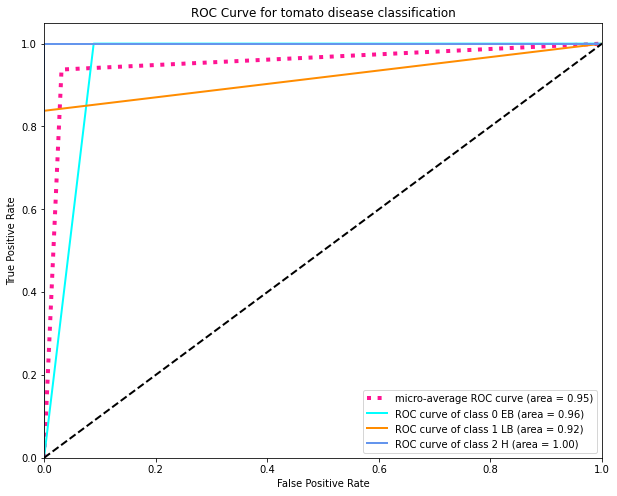

In [73]:
colors = ['aqua', 'darkorange', 'cornflowerblue']
lw=2
plt.figure(figsize=(10,8))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)
labels=['EB','LB','H']
for i,color in zip(range(n_classes),colors):
     plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
             ''.format(i, name=labels[i],area=roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for tomato disease classification')
plt.legend(loc="lower right")
# plt.show()
plt.savefig("./images/RocSVMPoly.png",dpi=400)

<h2>Linear Kernel</h2>

<h2> Hyperparameter</h2>

In [74]:
params={'C':C,'gamma':sigma,'kernel':['linear']}
grid_s=GridSearchCV(SVC(),params,refit=True,verbose=3)
grid_s.fit(X_train,y)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END .C=0.01, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END .C=0.01, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END .C=0.01, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END .C=0.01, gamma=0.01, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END .C=0.01, gamma=0.01, kernel=linear;, score=0.875 total time=   0.0s
[CV 1/5] END .C=0.01, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END .C=0.01, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END .C=0.01, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END .C=0.01, gamma=0.03, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END .C=0.01, gamma=0.03, kernel=linear;, score=0.875 total time=   0.0s
[CV 1/5] END ..C=0.01, gamma=0.1, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END ..C=0.01, gamma=0.1, kernel=linear

[CV 2/5] END .....C=0.1, gamma=3, kernel=linear;, score=0.875 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=3, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=3, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=3, kernel=linear;, score=0.917 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=10, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=10, kernel=linear;, score=0.875 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=10, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=10, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=10, kernel=linear;, score=0.917 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=30, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=30, kernel=linear;, score=0.875 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=30, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END ....C=0.1, gamm

[CV 2/5] END ....C=3, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END ....C=3, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END ....C=3, gamma=0.01, kernel=linear;, score=0.917 total time=   0.0s
[CV 5/5] END ....C=3, gamma=0.01, kernel=linear;, score=0.875 total time=   0.0s
[CV 1/5] END ....C=3, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END ....C=3, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END ....C=3, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END ....C=3, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 5/5] END ....C=3, gamma=0.03, kernel=linear;, score=0.875 total time=   0.0s
[CV 1/5] END .....C=3, gamma=0.1, kernel=linear;, score=0.917 total time=   0.0s
[CV 2/5] END .....C=3, gamma=0.1, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END .....C=3, gamma=0.1, kernel=linear;, score=0.917 total time=   0.0s
[CV 4/5] END .....C=3, gamma

[CV 3/5] END ..C=100, gamma=0.01, kernel=linear;, score=0.875 total time=   0.0s
[CV 4/5] END ..C=100, gamma=0.01, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END ..C=100, gamma=0.01, kernel=linear;, score=0.833 total time=   0.0s
[CV 1/5] END ..C=100, gamma=0.03, kernel=linear;, score=0.958 total time=   0.0s
[CV 2/5] END ..C=100, gamma=0.03, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END ..C=100, gamma=0.03, kernel=linear;, score=0.875 total time=   0.0s
[CV 4/5] END ..C=100, gamma=0.03, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END ..C=100, gamma=0.03, kernel=linear;, score=0.833 total time=   0.0s
[CV 1/5] END ...C=100, gamma=0.1, kernel=linear;, score=0.958 total time=   0.0s
[CV 2/5] END ...C=100, gamma=0.1, kernel=linear;, score=0.917 total time=   0.0s
[CV 3/5] END ...C=100, gamma=0.1, kernel=linear;, score=0.875 total time=   0.0s
[CV 4/5] END ...C=100, gamma=0.1, kernel=linear;, score=0.833 total time=   0.0s
[CV 5/5] END ...C=100, gamma

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'kernel': ['linear']},
             verbose=3)

In [75]:
print(grid_s.best_params_)
print(grid_s.best_estimator_)

{'C': 1, 'gamma': 0.01, 'kernel': 'linear'}
SVC(C=1, gamma=0.01, kernel='linear')


In [76]:
model=SVC(C=1, gamma=0.01, kernel='linear')
model.fit(X_train,y)

SVC(C=1, gamma=0.01, kernel='linear')

<h2>Predictions</h2>

In [77]:
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.115955,1.152092,-0.063260,-0.063260,0.663416,1.257780,0.755880,-0.444491,0.569418,-0.598628,...,0.138458,0.159867,0.101277,0.529910,1.152092,0.854109,0.827370,0.661432,-0.698731,-1.088670
1,-0.644152,-0.067471,-0.570890,-0.570890,0.305115,0.562541,-0.506573,0.703553,-0.656922,0.618894,...,-0.635841,-0.669291,-0.590586,-0.667035,-0.067471,-0.496450,0.648385,-0.589191,0.551824,0.181128
2,0.520059,2.598176,-0.349695,-0.349695,1.389672,1.896021,1.325791,-0.652310,0.815626,-0.919408,...,0.567620,0.505509,0.598211,0.749419,2.598176,1.234232,1.437455,0.689112,-1.163883,-2.300985
3,-0.856370,-0.551674,-1.554955,-1.554955,-1.160467,-0.800335,-0.712855,0.844693,-0.837531,0.756352,...,-0.855399,-0.844815,-0.880083,-0.853280,-0.551674,-0.709546,0.964802,-0.974671,0.726473,0.573161
4,0.069056,1.576752,-0.143906,-0.143906,2.038404,2.544765,0.530200,-0.012862,0.117843,-0.199718,...,0.101922,0.003116,0.244472,0.091031,1.576752,0.530089,1.037520,0.258099,-0.401019,-1.347249


In [78]:
y_test=y_cp
print(y_test.value_counts())
y_test.head()

1    74
2    61
0    57
Name: class, dtype: int64


0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

In [80]:
predictions=model.predict(X_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.80      0.98      0.88        57
           1       0.98      0.81      0.89        74
           2       1.00      1.00      1.00        61

    accuracy                           0.92       192
   macro avg       0.93      0.93      0.92       192
weighted avg       0.93      0.92      0.92       192

0    70
1    61
2    61
dtype: int64
Accuracy score =0.921875


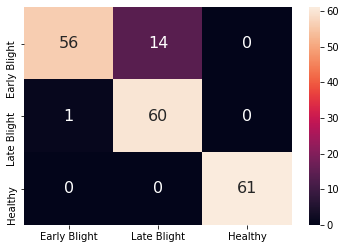

In [83]:
plot_matrix(y_test,predictions,"./images/Linear Kernel/ConfMatrixLinearSVM.png")

<h2> ROC Curves</h2>

In [87]:
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for tomato disease classification')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=400)

0: 70
1 :61
2 :61


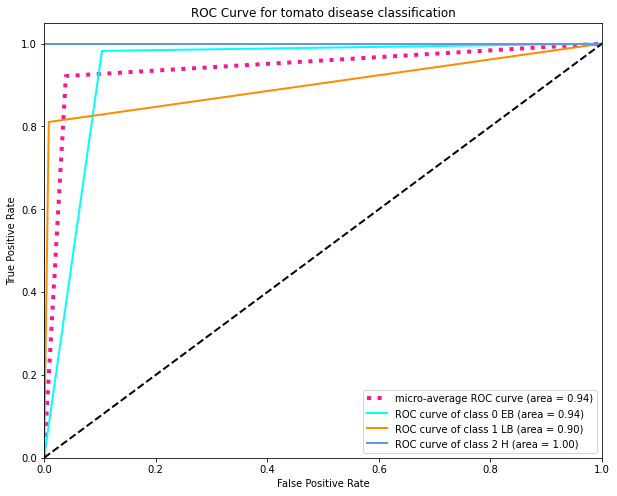

In [88]:
plot_roc(y_test,predictions,"./images/Linear Kernel/ROCSVMLinear.png")

<h2>Sigmoid Kernel</h2>

<h2>Hyperparameter</h2>

In [89]:
params={'C':C,'gamma':sigma,'kernel':['sigmoid']}
grid_s=GridSearchCV(SVC(),params,refit=True,verbose=3)
grid_s.fit(X_train,y)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END C=0.01, gamma=0.01, kernel=sigmoid;, score=0.708 total time=   0.0s
[CV 2/5] END C=0.01, gamma=0.01, kernel=sigmoid;, score=0.708 total time=   0.0s
[CV 3/5] END C=0.01, gamma=0.01, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 4/5] END C=0.01, gamma=0.01, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 5/5] END C=0.01, gamma=0.01, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 1/5] END C=0.01, gamma=0.03, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 2/5] END C=0.01, gamma=0.03, kernel=sigmoid;, score=0.708 total time=   0.0s
[CV 3/5] END C=0.01, gamma=0.03, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 4/5] END C=0.01, gamma=0.03, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 5/5] END C=0.01, gamma=0.03, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 1/5] END .C=0.01, gamma=0.1, kernel=sigmoid;, score=0.625 total time=   0.0s
[CV 2/5] END .C=0.01, gamma=0.1, kernel=sigmoid

[CV 3/5] END ..C=0.1, gamma=0.1, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 4/5] END ..C=0.1, gamma=0.1, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 5/5] END ..C=0.1, gamma=0.1, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 1/5] END ..C=0.1, gamma=0.3, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 2/5] END ..C=0.1, gamma=0.3, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 3/5] END ..C=0.1, gamma=0.3, kernel=sigmoid;, score=0.708 total time=   0.0s
[CV 4/5] END ..C=0.1, gamma=0.3, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 5/5] END ..C=0.1, gamma=0.3, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.708 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 5/5] END ....C=0.1, gamm

[CV 3/5] END .....C=1, gamma=30, kernel=sigmoid;, score=0.500 total time=   0.0s
[CV 4/5] END .....C=1, gamma=30, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 5/5] END .....C=1, gamma=30, kernel=sigmoid;, score=0.583 total time=   0.0s
[CV 1/5] END ....C=1, gamma=100, kernel=sigmoid;, score=0.583 total time=   0.0s
[CV 2/5] END ....C=1, gamma=100, kernel=sigmoid;, score=0.625 total time=   0.0s
[CV 3/5] END ....C=1, gamma=100, kernel=sigmoid;, score=0.500 total time=   0.0s
[CV 4/5] END ....C=1, gamma=100, kernel=sigmoid;, score=0.792 total time=   0.0s
[CV 5/5] END ....C=1, gamma=100, kernel=sigmoid;, score=0.542 total time=   0.0s
[CV 1/5] END ...C=3, gamma=0.01, kernel=sigmoid;, score=0.917 total time=   0.0s
[CV 2/5] END ...C=3, gamma=0.01, kernel=sigmoid;, score=0.875 total time=   0.0s
[CV 3/5] END ...C=3, gamma=0.01, kernel=sigmoid;, score=0.917 total time=   0.0s
[CV 4/5] END ...C=3, gamma=0.01, kernel=sigmoid;, score=0.833 total time=   0.0s
[CV 5/5] END ...C=3, gamma=0

[CV 2/5] END ...C=30, gamma=0.3, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 3/5] END ...C=30, gamma=0.3, kernel=sigmoid;, score=0.417 total time=   0.0s
[CV 4/5] END ...C=30, gamma=0.3, kernel=sigmoid;, score=0.625 total time=   0.0s
[CV 5/5] END ...C=30, gamma=0.3, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 1/5] END .....C=30, gamma=1, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 2/5] END .....C=30, gamma=1, kernel=sigmoid;, score=0.583 total time=   0.0s
[CV 3/5] END .....C=30, gamma=1, kernel=sigmoid;, score=0.542 total time=   0.0s
[CV 4/5] END .....C=30, gamma=1, kernel=sigmoid;, score=0.750 total time=   0.0s
[CV 5/5] END .....C=30, gamma=1, kernel=sigmoid;, score=0.667 total time=   0.0s
[CV 1/5] END .....C=30, gamma=3, kernel=sigmoid;, score=0.500 total time=   0.0s
[CV 2/5] END .....C=30, gamma=3, kernel=sigmoid;, score=0.625 total time=   0.0s
[CV 3/5] END .....C=30, gamma=3, kernel=sigmoid;, score=0.458 total time=   0.0s
[CV 4/5] END .....C=30, gamm

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'kernel': ['sigmoid']},
             verbose=3)

In [90]:
print(grid_s.best_params_)
print(grid_s.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'sigmoid'}
SVC(C=10, gamma=0.01, kernel='sigmoid')


In [91]:
model=SVC(C=10, gamma=0.01, kernel='sigmoid')
model.fit(X_train,y)

SVC(C=10, gamma=0.01, kernel='sigmoid')

<h2>Predictions</h2>

In [92]:
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.115955,1.152092,-0.063260,-0.063260,0.663416,1.257780,0.755880,-0.444491,0.569418,-0.598628,...,0.138458,0.159867,0.101277,0.529910,1.152092,0.854109,0.827370,0.661432,-0.698731,-1.088670
1,-0.644152,-0.067471,-0.570890,-0.570890,0.305115,0.562541,-0.506573,0.703553,-0.656922,0.618894,...,-0.635841,-0.669291,-0.590586,-0.667035,-0.067471,-0.496450,0.648385,-0.589191,0.551824,0.181128
2,0.520059,2.598176,-0.349695,-0.349695,1.389672,1.896021,1.325791,-0.652310,0.815626,-0.919408,...,0.567620,0.505509,0.598211,0.749419,2.598176,1.234232,1.437455,0.689112,-1.163883,-2.300985
3,-0.856370,-0.551674,-1.554955,-1.554955,-1.160467,-0.800335,-0.712855,0.844693,-0.837531,0.756352,...,-0.855399,-0.844815,-0.880083,-0.853280,-0.551674,-0.709546,0.964802,-0.974671,0.726473,0.573161
4,0.069056,1.576752,-0.143906,-0.143906,2.038404,2.544765,0.530200,-0.012862,0.117843,-0.199718,...,0.101922,0.003116,0.244472,0.091031,1.576752,0.530089,1.037520,0.258099,-0.401019,-1.347249


In [95]:
print(y_test.value_counts())

1    74
2    61
0    57
Name: class, dtype: int64


In [96]:
predictions=model.predict(X_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.77      0.95      0.85        57
           1       0.95      0.78      0.86        74
           2       1.00      1.00      1.00        61

    accuracy                           0.90       192
   macro avg       0.91      0.91      0.90       192
weighted avg       0.91      0.90      0.90       192

0    70
1    61
2    61
dtype: int64
Accuracy score =0.9010416666666666


<h2>Confusion Matrix</h2>

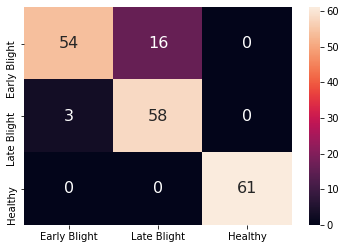

In [97]:
plot_matrix(y_test,predictions,"./images/Sigmoid Kernel/ConfMatrixSigmoidSVM.png")

<h2>ROC Curve</h2>

0: 70
1 :61
2 :61


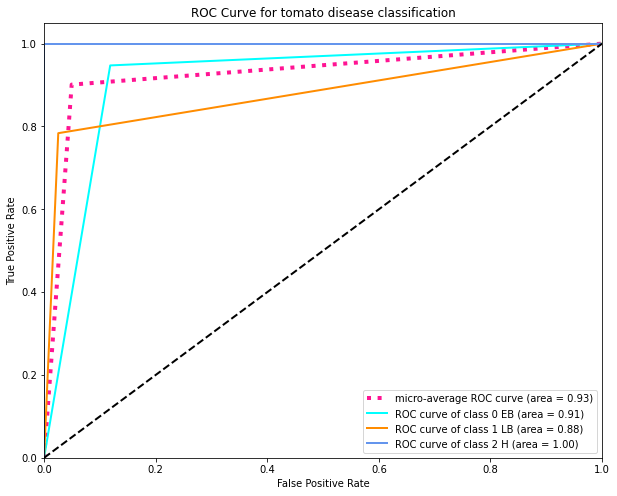

In [98]:
plot_roc(y_test,predictions,"./images/Sigmoid Kernel/ROCSVMSigmoid.png")